# Proximal Policy Optimazation



In [1]:
import gymnasium as gym
import numpy as np
import torch
from torch import Tensor
from torch.distributions import Categorical
from typing import Sequence, Tuple, Dict

from pg_env import (
    ActionSample,
    BatchUpdateAgent,
    MLPPolicy,
    MLPValue,
    RolloutBatch,
    make_cartpole_env,
    plot_training_history,
    set_seed,
    to_tensor,
    train_on_policy_batches,
    run_demo_episode
)

In [2]:
def normalize_tensor(x: Tensor, eps: float = 1e-8) -> Tensor:
    """
    Normalize a tensor to zero mean and unit std.
    """
    if x.numel() <= 1:
        return x
    return (x - x.mean()) / (x.std() + eps)


def compute_gae_and_returns(
    rewards: Tensor,
    values: Tensor,
    dones: Tensor,
    gamma: float,
    gae_lambda: float,
) -> Tuple[Tensor, Tensor]:
    """
    Compute GAE-Lambda advantages and returns for a flattened rollout batch.

    Args:
        rewards: shape [T]
        values: shape [T]
        dones: shape [T], bool tensor marking end of episode
        gamma: discount factor
        gae_lambda: lambda for GAE

    Returns:
        advantages: shape [T]
        returns: shape [T]
    """
    T = rewards.shape[0]
    advantages = torch.zeros_like(rewards)
    last_gae = 0.0

    for t in reversed(range(T)):
        if t == T - 1 or dones[t]:
            next_value = 0.0
            next_nonterminal = 0.0
        else:
            next_value = values[t + 1]
            next_nonterminal = 1.0

        delta = rewards[t] + gamma * next_value * next_nonterminal - values[t]
        last_gae = delta + gamma * gae_lambda * next_nonterminal * last_gae
        advantages[t] = last_gae

    returns = advantages + values
    return advantages, returns


def iter_minibatch_indices(
    n: int,
    minibatch_size: int,
    shuffle: bool = True,
):
    """
    Yield index arrays for minibatches.
    """
    indices = np.arange(n)
    if shuffle:
        np.random.shuffle(indices)

    for start in range(0, n, minibatch_size):
        yield indices[start:start + minibatch_size]

In [3]:



class PPOAgent(BatchUpdateAgent):
    """
    PPO agent for discrete action spaces.

    This version is designed to work with your current pg_env.py:
    - collects rollout data through ActionSample
    - updates from RolloutBatch
    - uses GAE + clipped policy objective
    """

    def __init__(
        self,
        obs_dim: int,
        act_dim: int,
        hidden_sizes: Sequence[int] = (64, 64),
        gamma: float = 0.99,
        gae_lambda: float = 0.97,
        clip_ratio: float = 0.2,
        policy_lr: float = 3e-4,
        value_lr: float = 1e-3,
        train_pi_iters: int = 10,
        train_v_iters: int = 10,
        minibatch_size: int = 256,
        target_kl: float = 0.01,
        entropy_coef: float = 0.0,
        value_coef: float = 0.5,
        device: torch.device | None = None,
    ) -> None:
        self.device = device or torch.device("cpu")

        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_ratio = clip_ratio
        self.train_pi_iters = train_pi_iters
        self.train_v_iters = train_v_iters
        self.minibatch_size = minibatch_size
        self.target_kl = target_kl
        self.entropy_coef = entropy_coef
        self.value_coef = value_coef

        self.policy = MLPPolicy(
            obs_dim=obs_dim,
            act_dim=act_dim,
            hidden_sizes=hidden_sizes,
        ).to(self.device)

        self.value_net = MLPValue(
            obs_dim=obs_dim,
            hidden_sizes=hidden_sizes,
        ).to(self.device)

        self.policy_optimizer = torch.optim.Adam(
            self.policy.parameters(),
            lr=policy_lr,
        )
        self.value_optimizer = torch.optim.Adam(
            self.value_net.parameters(),
            lr=value_lr,
        )

    def _dist(self, obs_tensor: Tensor) -> Categorical:
        """
        Build the action distribution for a batch of observations.
        """
        logits = self.policy(obs_tensor)
        return Categorical(logits=logits)

    def sample_action(self, obs: np.ndarray) -> ActionSample:
        """
        Sampling API used by pg_env during rollout collection.
        """
        obs_tensor = to_tensor(obs, self.device)

        with torch.no_grad():
            dist = self._dist(obs_tensor)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            value = self.value_net(obs_tensor)

        return ActionSample(
            action=int(action.item()),
            log_prob=log_prob.detach().view(1),
            value=value.detach().view(1),
        )

    def predict_action(self, obs: np.ndarray) -> int:
        """
        Greedy action used in evaluation/demo.
        """
        with torch.no_grad():
            obs_tensor = to_tensor(obs, self.device)
            logits = self.policy(obs_tensor)
            action = torch.argmax(logits, dim=-1)
            return int(action.item())

    def update_from_batch(self, batch: RolloutBatch) -> Dict[str, float]:
        """
        Main PPO update.
        """
        obs = torch.as_tensor(
            np.asarray(batch.observations),
            dtype=torch.float32,
            device=self.device,
        )
        actions = torch.as_tensor(
            batch.actions,
            dtype=torch.int64,
            device=self.device,
        )
        rewards = torch.as_tensor(
            batch.rewards,
            dtype=torch.float32,
            device=self.device,
        )
        dones = torch.as_tensor(
            batch.dones,
            dtype=torch.bool,
            device=self.device,
        )

        # Old log-probs were stored at rollout time.
        old_log_probs = torch.cat(
            [lp.view(1) for lp in batch.log_probs if lp is not None]
        ).to(self.device)

        # Compute baseline values from the old policy/value state.
        with torch.no_grad():
            old_values = self.value_net(obs)

        advantages, returns = compute_gae_and_returns(
            rewards=rewards,
            values=old_values,
            dones=dones,
            gamma=self.gamma,
            gae_lambda=self.gae_lambda,
        )
        advantages = normalize_tensor(advantages)

        n = obs.shape[0]

        policy_loss_history = []
        value_loss_history = []
        approx_kl_history = []
        entropy_history = []
        clip_fraction_history = []

        stop_early = False
        policy_updates_done = 0

        # Policy updates
        for _ in range(self.train_pi_iters):
            for mb_idx in iter_minibatch_indices(n, self.minibatch_size, shuffle=True):
                mb_idx_t = torch.as_tensor(mb_idx, dtype=torch.int64, device=self.device)

                obs_mb = obs[mb_idx_t]
                actions_mb = actions[mb_idx_t]
                old_log_probs_mb = old_log_probs[mb_idx_t]
                advantages_mb = advantages[mb_idx_t]

                dist = self._dist(obs_mb)
                new_log_probs = dist.log_prob(actions_mb)
                entropy = dist.entropy().mean()

                ratio = torch.exp(new_log_probs - old_log_probs_mb)

                unclipped_obj = ratio * advantages_mb
                clipped_ratio = torch.clamp(
                    ratio,
                    1.0 - self.clip_ratio,
                    1.0 + self.clip_ratio,
                )
                clipped_obj = clipped_ratio * advantages_mb

                policy_loss = -torch.mean(torch.min(unclipped_obj, clipped_obj))
                total_policy_loss = policy_loss - self.entropy_coef * entropy

                self.policy_optimizer.zero_grad()
                total_policy_loss.backward()
                self.policy_optimizer.step()

                with torch.no_grad():
                    approx_kl = torch.mean(old_log_probs_mb - new_log_probs)
                    clip_fraction = torch.mean(
                        (torch.abs(ratio - 1.0) > self.clip_ratio).float()
                    )

                policy_loss_history.append(float(policy_loss.item()))
                approx_kl_history.append(float(approx_kl.item()))
                entropy_history.append(float(entropy.item()))
                clip_fraction_history.append(float(clip_fraction.item()))
                policy_updates_done += 1

                if approx_kl.item() > 1.5 * self.target_kl:
                    stop_early = True
                    break

            if stop_early:
                break

        # Value updates
        for _ in range(self.train_v_iters):
            for mb_idx in iter_minibatch_indices(n, self.minibatch_size, shuffle=True):
                mb_idx_t = torch.as_tensor(mb_idx, dtype=torch.int64, device=self.device)

                obs_mb = obs[mb_idx_t]
                returns_mb = returns[mb_idx_t]

                values_pred = self.value_net(obs_mb)
                value_loss = torch.mean((values_pred - returns_mb) ** 2)

                self.value_optimizer.zero_grad()
                value_loss.backward()
                self.value_optimizer.step()

                value_loss_history.append(float(value_loss.item()))

        # Final full-batch diagnostics
        with torch.no_grad():
            final_dist = self._dist(obs)
            final_log_probs = final_dist.log_prob(actions)
            final_entropy = final_dist.entropy().mean()

            ratio = torch.exp(final_log_probs - old_log_probs)
            clipped_ratio = torch.clamp(
                ratio,
                1.0 - self.clip_ratio,
                1.0 + self.clip_ratio,
            )

            unclipped_obj = ratio * advantages
            clipped_obj = clipped_ratio * advantages
            final_policy_loss = -torch.mean(torch.min(unclipped_obj, clipped_obj))

            final_values = self.value_net(obs)
            final_value_loss = torch.mean((final_values - returns) ** 2)

            final_approx_kl = torch.mean(old_log_probs - final_log_probs)
            final_clip_fraction = torch.mean(
                (torch.abs(ratio - 1.0) > self.clip_ratio).float()
            )

        return {
            "policy_loss": float(final_policy_loss.item()),
            "value_loss": float(final_value_loss.item()),
            "entropy": float(final_entropy.item()),
            "approx_kl": float(final_approx_kl.item()),
            "clip_fraction": float(final_clip_fraction.item()),
            "mean_ratio": float(ratio.mean().item()),
            "policy_updates_done": float(policy_updates_done),
            "early_stop": 1.0 if stop_early else 0.0,
            "batch_mean_return": float(batch.mean_episode_return),
            "adv_mean": float(advantages.mean().item()),
            "adv_std": float(advantages.std().item()),
            "mean_policy_loss_step": float(np.mean(policy_loss_history)) if policy_loss_history else 0.0,
            "mean_value_loss_step": float(np.mean(value_loss_history)) if value_loss_history else 0.0,
        }


def build_ppo_agent_from_env(
    env_fn,
    hidden_sizes = (64, 64),
    gamma: float = 0.99,
    gae_lambda: float = 0.97,
    clip_ratio: float = 0.2,
    policy_lr: float = 3e-4,
    value_lr: float = 1e-3,
    train_pi_iters: int = 10,
    train_v_iters: int = 10,
    minibatch_size: int = 256,
    target_kl: float = 0.01,
    entropy_coef: float = 0.0,
    value_coef: float = 0.5,
    device: torch.device | None = None,
) -> PPOAgent:
    """
    Infer env dimensions and build a PPO agent.
    """
    env = env_fn()

    assert isinstance(env.observation_space, gym.spaces.Box), "Expected Box observation space."
    assert isinstance(env.action_space, gym.spaces.Discrete), "Expected Discrete action space."

    obs_dim = int(np.prod(env.observation_space.shape))
    act_dim = int(env.action_space.n)

    env.close()

    return PPOAgent(
        obs_dim=obs_dim,
        act_dim=act_dim,
        hidden_sizes=hidden_sizes,
        gamma=gamma,
        gae_lambda=gae_lambda,
        clip_ratio=clip_ratio,
        policy_lr=policy_lr,
        value_lr=value_lr,
        train_pi_iters=train_pi_iters,
        train_v_iters=train_v_iters,
        minibatch_size=minibatch_size,
        target_kl=target_kl,
        entropy_coef=entropy_coef,
        value_coef=value_coef,
        device=device,
    )

[iter    1] batch_mean_return=  22.51 | steps= 4120 | episodes=183 | eval_mean_return=  34.00 | policy_loss=  -0.0163
[iter    5] batch_mean_return=  43.08 | steps= 4136 | episodes= 96 | eval_mean_return=  87.80 | policy_loss=  -0.0223
[iter   10] batch_mean_return= 185.67 | steps= 4456 | episodes= 24 | eval_mean_return= 500.00 | policy_loss=  -0.0079
[iter   15] batch_mean_return= 229.17 | steps= 4125 | episodes= 18 | eval_mean_return= 487.00 | policy_loss=  -0.0059
[iter   20] batch_mean_return= 473.78 | steps= 4264 | episodes=  9 | eval_mean_return= 432.20 | policy_loss=  -0.0013
[iter   25] batch_mean_return= 437.50 | steps= 4375 | episodes= 10 | eval_mean_return= 500.00 | policy_loss=  -0.0050
[iter   30] batch_mean_return= 500.00 | steps= 4500 | episodes=  9 | eval_mean_return= 500.00 | policy_loss=  -0.0031
[iter   35] batch_mean_return= 500.00 | steps= 4500 | episodes=  9 | eval_mean_return= 500.00 | policy_loss=  -0.0010
[iter   40] batch_mean_return= 500.00 | steps= 4500 | ep

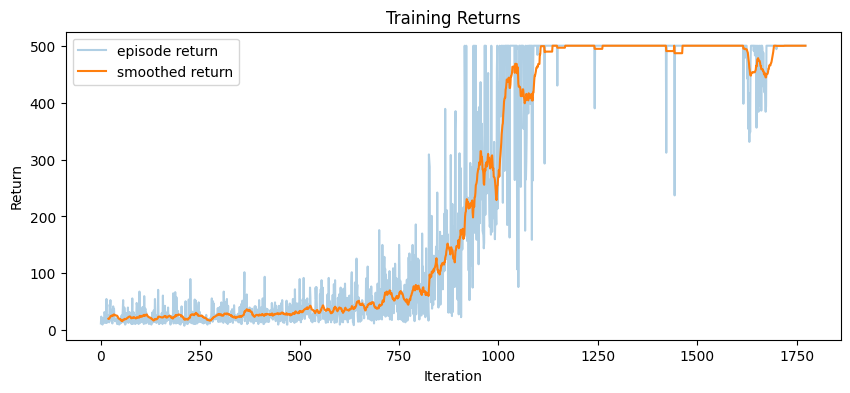

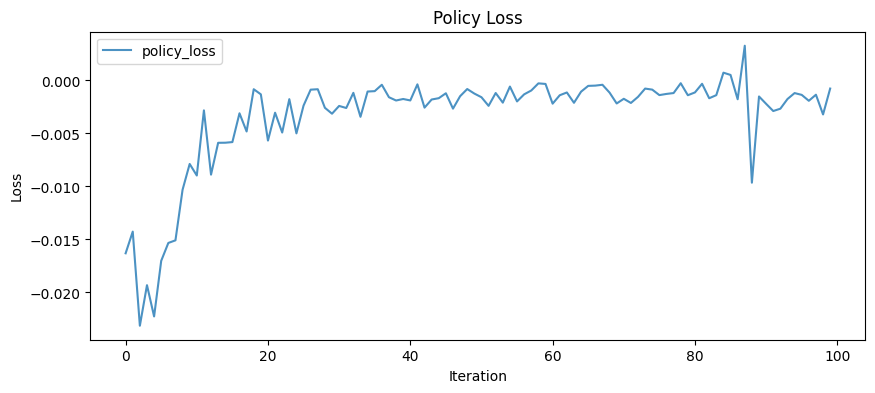

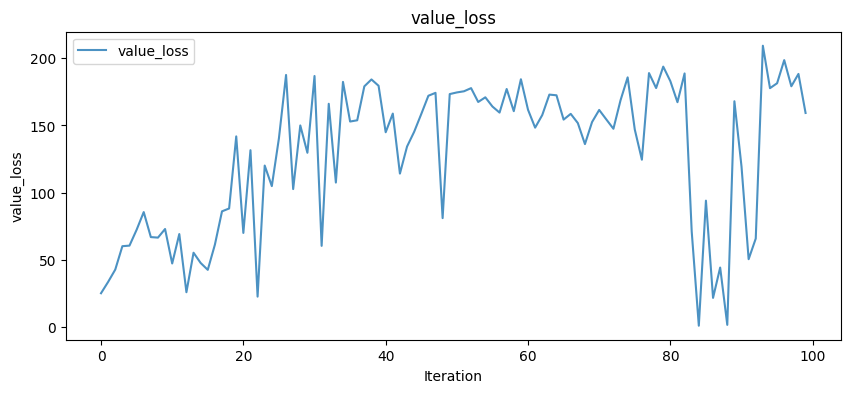

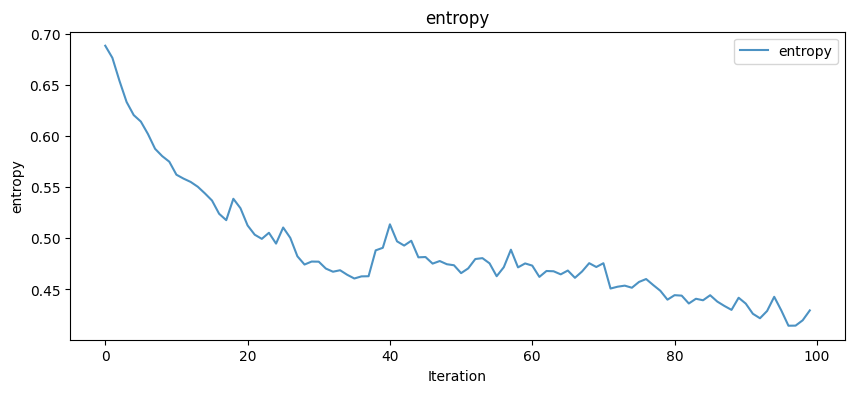

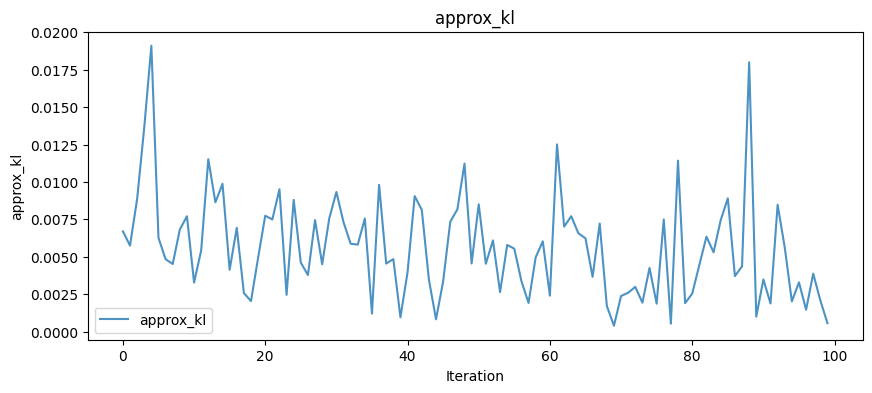

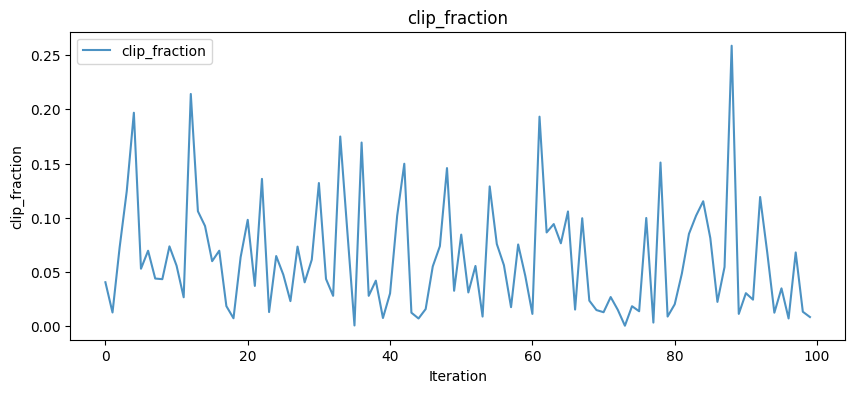

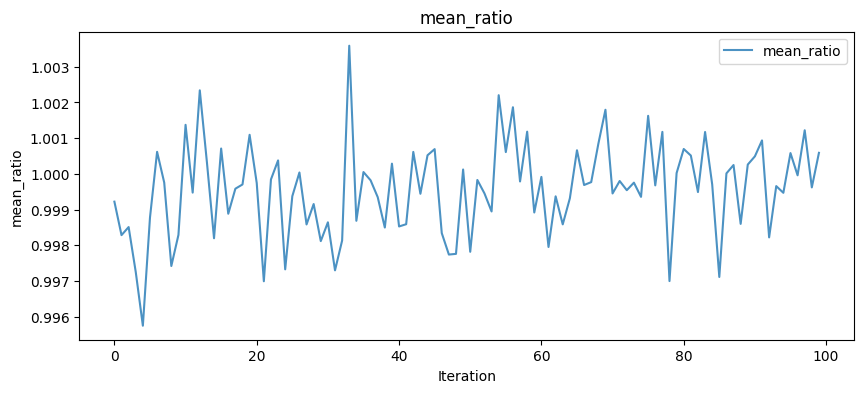

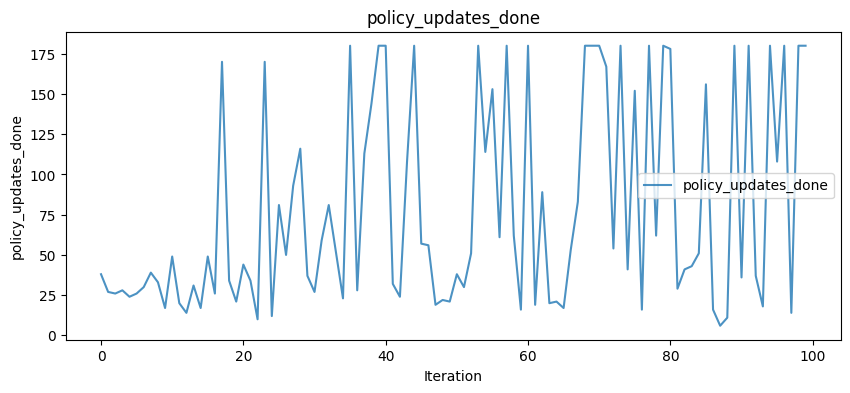

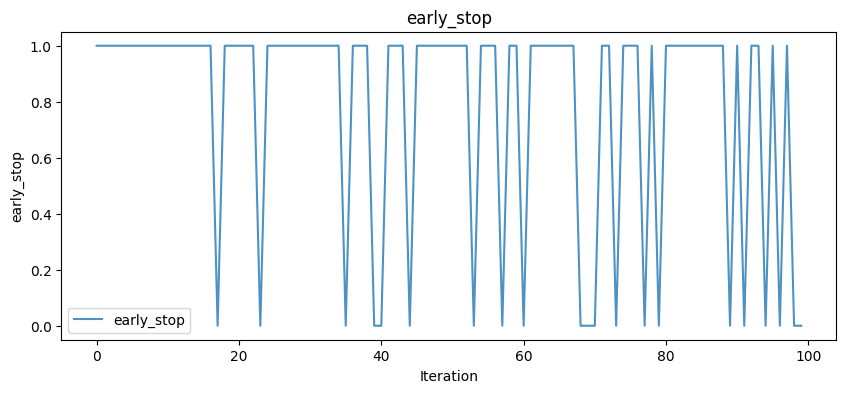

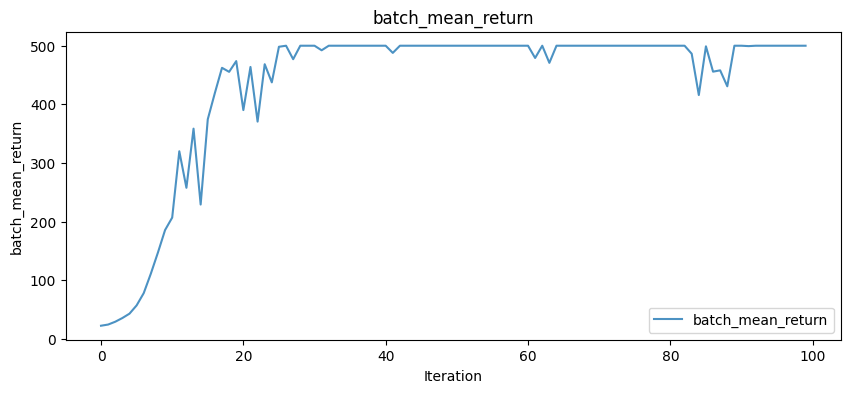

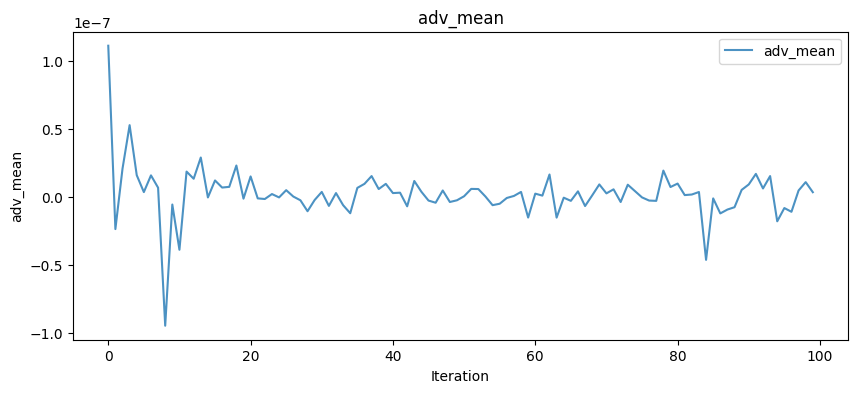

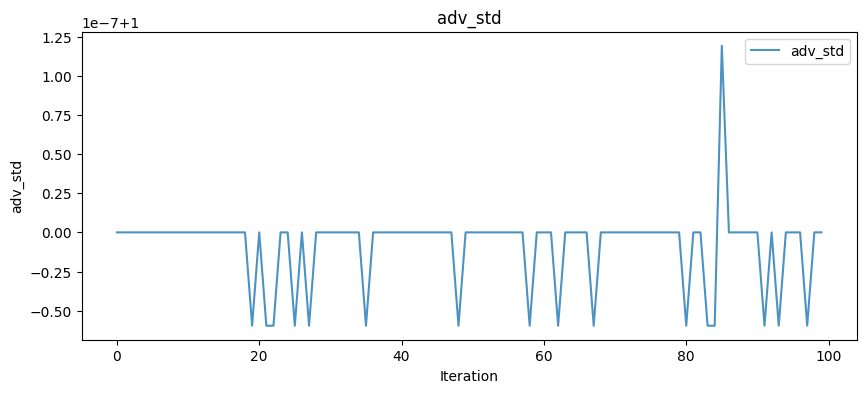

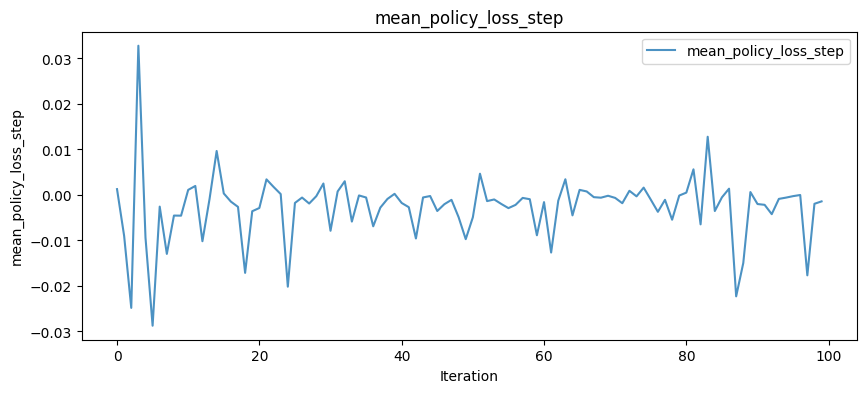

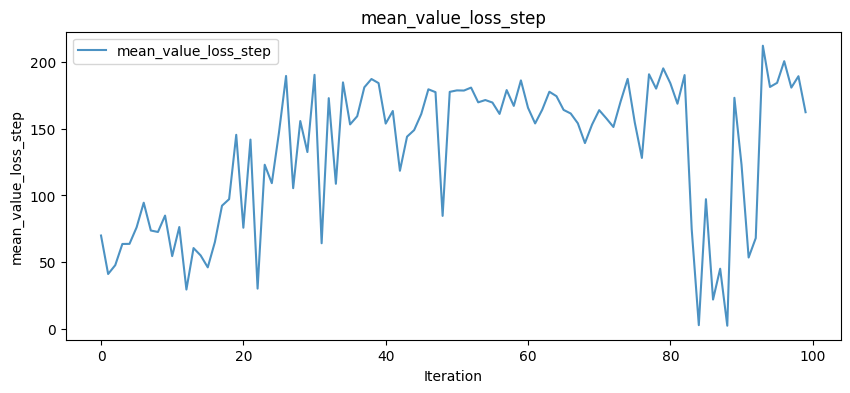

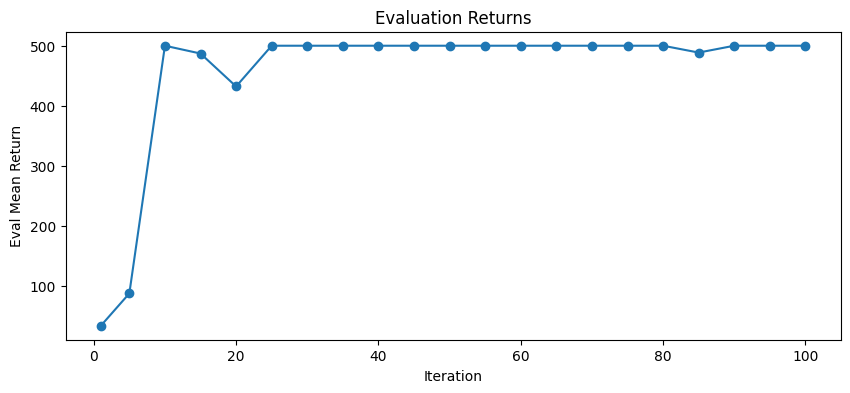

In [4]:
set_seed(42)

env_fn = lambda: make_cartpole_env(render_mode=None)

agent = build_ppo_agent_from_env(
    env_fn=env_fn,
    hidden_sizes=(64, 64),
    gamma=0.99,
    gae_lambda=0.97,
    clip_ratio=0.2,
    policy_lr=3e-4,
    value_lr=1e-3,
    train_pi_iters=10,
    train_v_iters=10,
    minibatch_size=256,
    target_kl=0.01,
    entropy_coef=0.0,
)

history = train_on_policy_batches(
    env_fn=env_fn,
    agent=agent,
    num_iterations=100,
    batch_size=4096,
    eval_every=5,
    eval_episodes=5,
    verbose=True,
)

plot_training_history(history)

In [5]:
visual_env = lambda: make_cartpole_env(render_mode="human")

run_demo_episode(visual_env, agent, greedy=True)

/mnt/hd/Repos/ds_be_like/.venv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Demo return: 500.00


500.0